In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


ModuleNotFoundError: No module named 'pandas'

C:\Users\Vyas\AppData\Local\Temp\ipykernel_5160\1884365337.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='ATC Level', y='LR', data=melted_data, inner=None, palette=palette, scale='width', linewidth=1.5)
C:\Users\Vyas\AppData\Local\Temp\ipykernel_5160\1884365337.py:21: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x='ATC Level', y='LR', data=melted_data, inner=None, palette=palette, scale='width', linewidth=1.5)


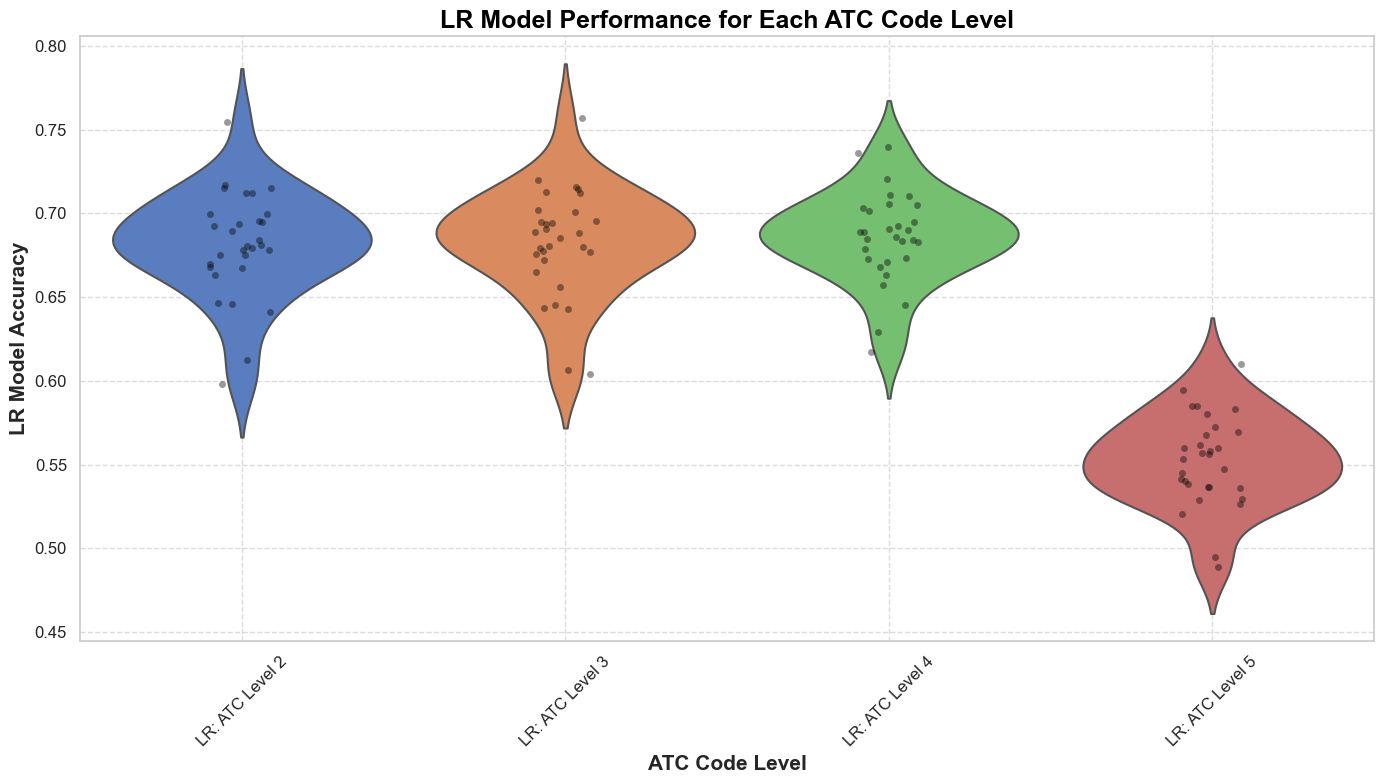

In [5]:
#VIOLIN + JITTER PLOT comparing LR model's performance across ATC levels

# Set the style for the plot
sns.set(style="whitegrid")

# Load the Excel file
file_path = 'LR_ANOVA_ATC_Level234.xlsx'
data = pd.read_excel(file_path)

# Melt the data for easier plotting
melted_data = pd.melt(data, id_vars=['Side Effect'], value_vars=['LR: ATC Level 2', 'LR: ATC Level 3', 'LR: ATC Level 4', 'LR: ATC Level 5'],
                      var_name='ATC Level', value_name='LR')

# Set a color palette
palette = sns.color_palette("muted", 4)

# Create the figure
plt.figure(figsize=(14, 8))

# Violin plot with jittered stripplot
sns.violinplot(x='ATC Level', y='LR', data=melted_data, inner=None, palette=palette, scale='width', linewidth=1.5)
sns.stripplot(x='ATC Level', y='LR', data=melted_data, jitter=True, color='black', alpha=0.4, size=5)

# Add title and labels with enhancements
plt.title('LR Model Performance for Each ATC Code Level', fontsize=18, fontweight='bold', color='black')
plt.xlabel('ATC Code Level', fontsize=15, fontweight='bold')
plt.ylabel('LR Model Accuracy', fontsize=15, fontweight='bold')

# Improve tick labels
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Add a grid for readability
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

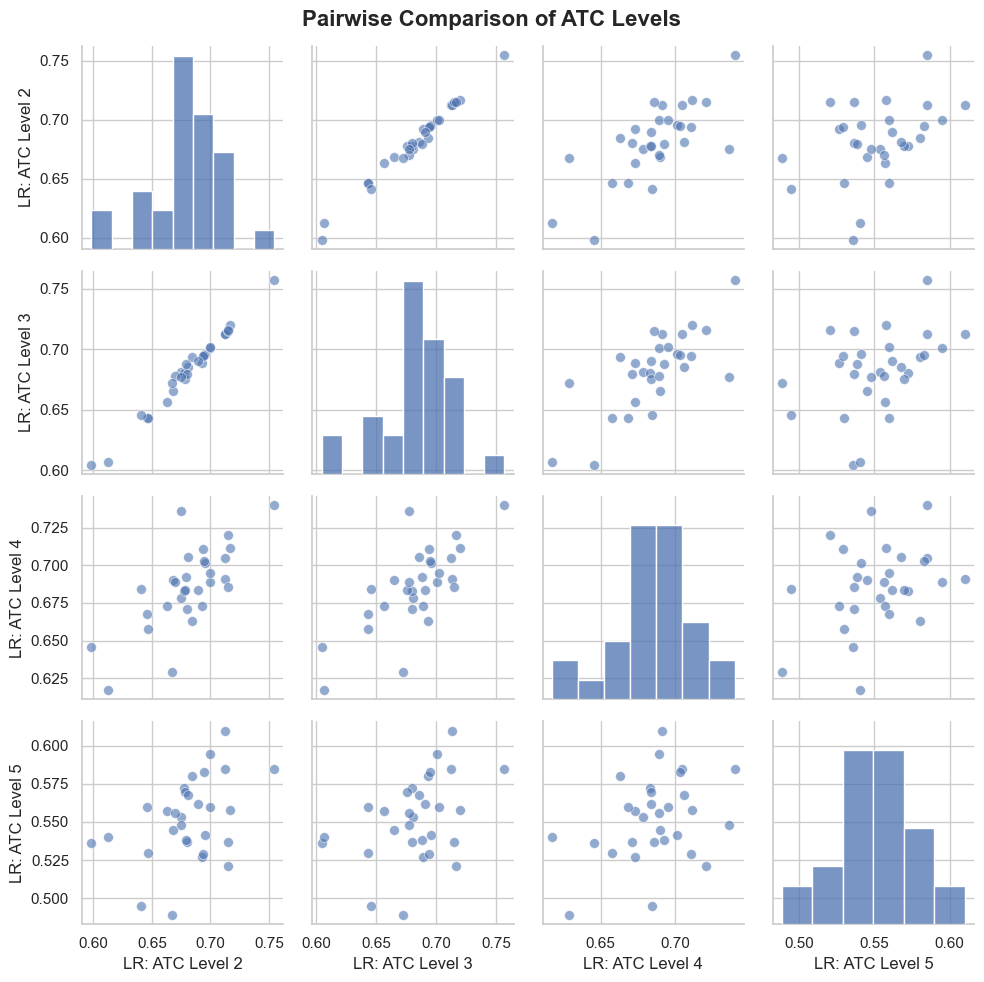

In [4]:
# PAIRWISE COMPARISON PLOT for each ATC level
# How to interpret: linear relationship means very similar performance; non linear means different
# The histograms on the diagonal show the distribution of each ATC level's performance.

# Select the columns for pairplot
pair_data = data[['LR: ATC Level 2', 'LR: ATC Level 3', 'LR: ATC Level 4', 'LR: ATC Level 5']]

# Plot a pairplot
sns.pairplot(pair_data, plot_kws={'alpha': 0.6, 's': 50}, height=2.5)

# Add title
plt.suptitle('Pairwise Comparison of ATC Levels', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

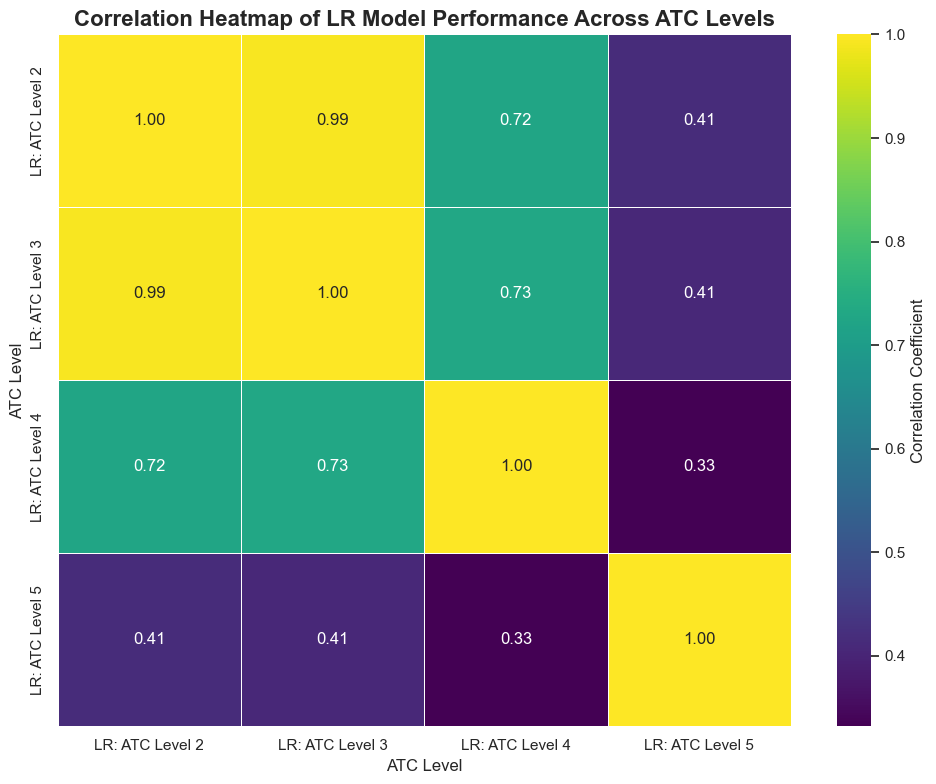

In [7]:
# CORRELATION HEATMAP for LR model performance across ATC levels
# Trying to show similar results to the pairwise plot: level two and three are incredibly similar.
# Level five is different but we know it's because it's poorer. Level four is somewhat different
# from the others, so we can take a closer look at it.

# Calculate the correlation matrix for the columns you want to analyze
corr_matrix = data[['LR: ATC Level 2', 'LR: ATC Level 3', 'LR: ATC Level 4', 'LR: ATC Level 5']].corr()

# Set the style for the plot
sns.set(style="white")

# Create the figure
plt.figure(figsize=(10, 8))

# Generate the heatmap with the 'viridis' color palette
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})

# Add title and labels
plt.title('Correlation Heatmap of LR Model Performance Across ATC Levels', fontsize=16, fontweight='bold')
plt.xlabel('ATC Level', fontsize=12)
plt.ylabel('ATC Level', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()


                   Side Effect  Mean Difference
29  musculoskeletal discomfort         0.060887
21          anaphylactic shock         0.047176
28                   infection         0.043446
11  body temperature increased         0.024643
0                    dizziness         0.021864
14   gastrointestinal disorder         0.021781
16                   dyspepsia         0.018852
18                    dyspnoea         0.017044
27                  arthralgia         0.013256
22                paraesthesia         0.010867
13                        pain         0.010000
10                   urticaria         0.008465
6                    diarrhoea         0.005906
3                         rash         0.005563
25            thrombocytopenia         0.005351
2                     headache         0.005190
24     nervous system disorder         0.004362
1                       nausea         0.003353
17                constipation        -0.004930
5                     asthenia        -0

C:\Users\Vyas\AppData\Local\Temp\ipykernel_5160\445926837.py:42: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Mean Difference', y='Side Effect', data=top_results, palette="viridis", ci=None)
C:\Users\Vyas\AppData\Local\Temp\ipykernel_5160\445926837.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mean Difference', y='Side Effect', data=top_results, palette="viridis", ci=None)


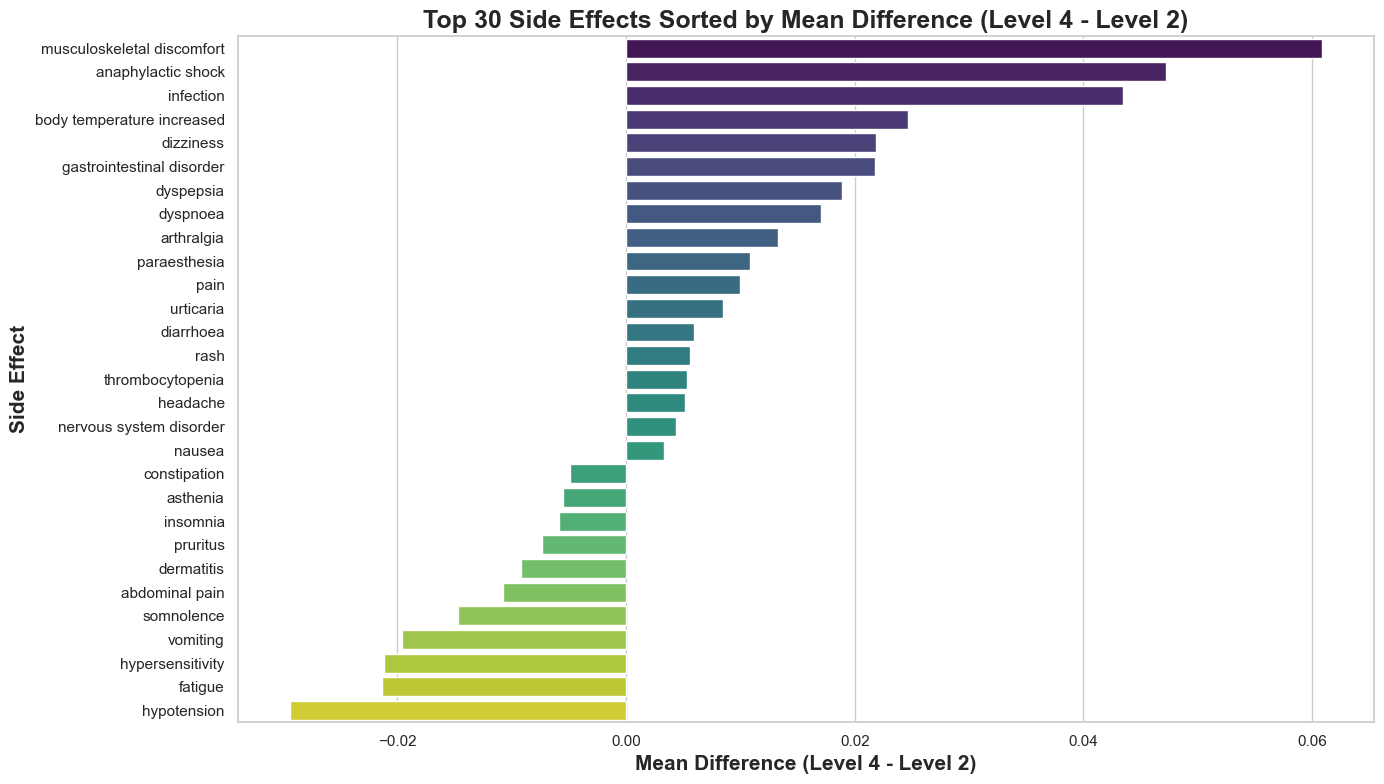

In [ ]:
# MEAN DIFFERENCE PLOT for the top 30 side effects. 
# Sorted by highest to lowest mean difference between ATC Level 2 and ATC Level 4


# Set the style for the plot
sns.set(style="whitegrid")

# Load the Excel file
file_path = 'LR_ANOVA_ATC_Level234.xlsx'
data = pd.read_excel(file_path)

# Extract the data for Level 2 and Level 4
level_2 = data['LR: ATC Level 2']
level_4 = data['LR: ATC Level 4']
side_effects = data['Side Effect']

# List to store p-values and mean differences
mean_differences = []
side_effect_names = []

# Calculate mean differences
for i in range(len(data)):
    # Calculate the mean difference between Level 2 and Level 4
    mean_diff = level_4[i] - level_2[i]

    # Append results to the lists
    mean_differences.append(mean_diff)
    side_effect_names.append(side_effects[i])

# Create a DataFrame for the results
results = pd.DataFrame({
    'Side Effect': side_effect_names,
    'Mean Difference': mean_differences
})

# Sort by Mean Difference
results_sorted = results.sort_values(by='Mean Difference', ascending=False)

# Print the sorted results (by mean difference)
print(results_sorted)

# Plot the most significant side effects based on mean difference
top_results = results_sorted.head(29)

plt.figure(figsize=(14, 8))
sns.barplot(x='Mean Difference', y='Side Effect', data=top_results, palette="viridis", ci=None)

# Add titles and labels
plt.title('Top 30 Side Effects Sorted by Mean Difference (Level 4 - Level 2)', fontsize=18, fontweight='bold')
plt.xlabel('Mean Difference (Level 4 - Level 2)', fontsize=15, fontweight='bold')
plt.ylabel('Side Effect', fontsize=15, fontweight='bold')

# Show the plot
plt.tight_layout()
plt.show()


                   Side Effect  Mean Difference
29  musculoskeletal discomfort         0.060887
21          anaphylactic shock         0.047176
28                   infection         0.043446
11  body temperature increased         0.024643
0                    dizziness         0.021864
14   gastrointestinal disorder         0.021781
16                   dyspepsia         0.018852
18                    dyspnoea         0.017044
27                  arthralgia         0.013256
22                paraesthesia         0.010867
13                        pain         0.010000
10                   urticaria         0.008465
6                    diarrhoea         0.005906
3                         rash         0.005563
25            thrombocytopenia         0.005351
2                     headache         0.005190
24     nervous system disorder         0.004362
1                       nausea         0.003353
17                constipation        -0.004930
5                     asthenia        -0

C:\Users\Vyas\AppData\Local\Temp\ipykernel_5160\114706957.py:42: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Mean Difference', y='Side Effect', data=top_results, palette="viridis", ci=None)
C:\Users\Vyas\AppData\Local\Temp\ipykernel_5160\114706957.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mean Difference', y='Side Effect', data=top_results, palette="viridis", ci=None)


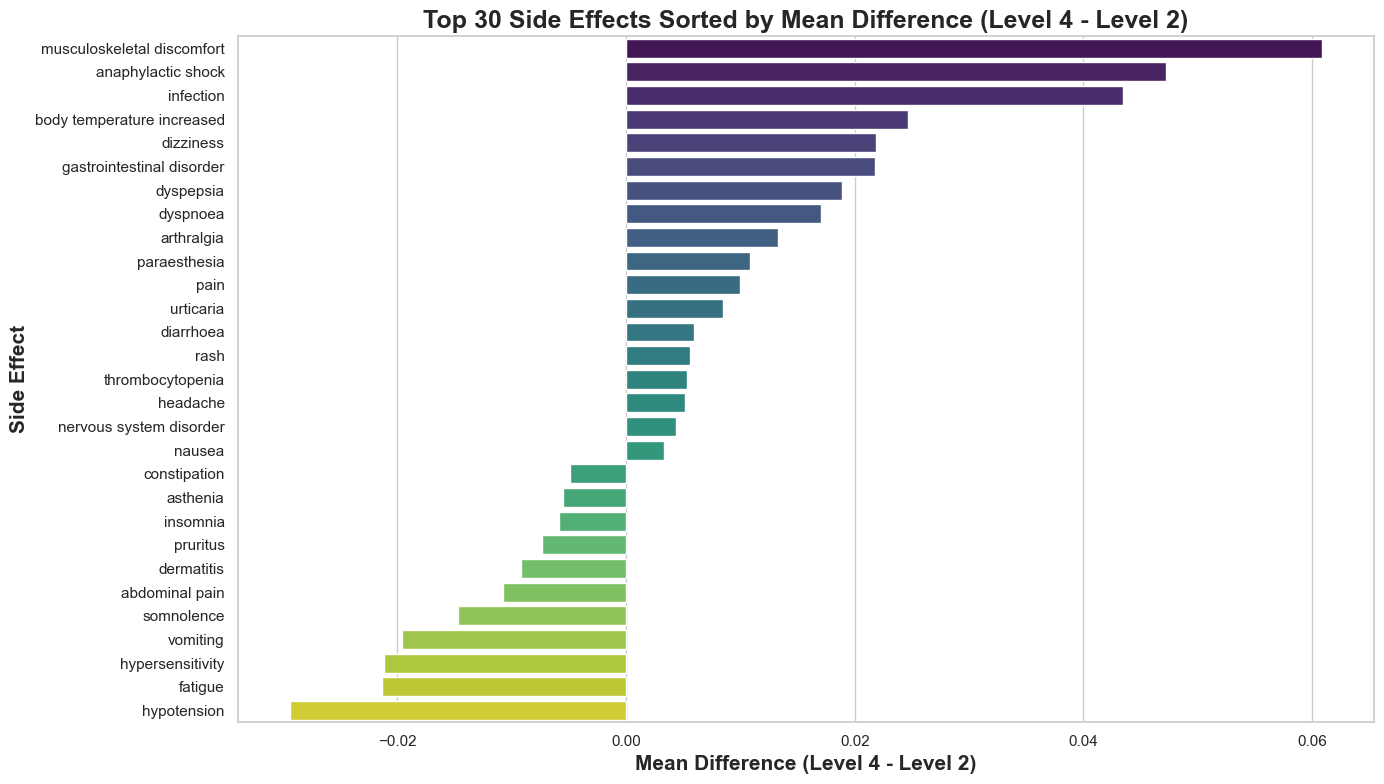

In [ ]:
# T-TEST comparing LR model's performance between ATC levels 2 and 4
# It's not significant so I'm not sure if we want to include it or not right now, but
# I might do a t-test for just some of the side effects rather than all thirty instead? We can discuss. 

# Set the style for the plot
sns.set(style="whitegrid")

# Extract the data for Level 2 and Level 4
level_2 = data['LR: ATC Level 2']
level_4 = data['LR: ATC Level 4']

# Perform a t-test comparing Level 2 and Level 4 across all side effects
t_stat, p_val = stats.ttest_ind(level_2, level_4)

# Print the results
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_val}")

# Visualize the comparison
plt.figure(figsize=(8, 6))

# Combine the Level 2 and Level 4 data into one DataFrame for easier plotting
comparison_data = pd.DataFrame({
    'Level': ['Level 2'] * len(level_2) + ['Level 4'] * len(level_4),
    'Value': list(level_2) + list(level_4)
})

# Create a boxplot to show the distribution
sns.boxplot(x='Level', y='Value', data=comparison_data, palette="Set2")

# Add titles and labels
plt.title('Comparison of Level 2 vs Level 4', fontsize=18, fontweight='bold')
plt.xlabel('ATC Level', fontsize=15, fontweight='bold')
plt.ylabel('Values', fontsize=15, fontweight='bold')

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
# MEAN DIFFERENCE PLOT for the top 30 side effects. 
# Sorted by highest to lowest mean difference between ATC Level 2 and ATC Level 4


# Set the style for the plot
sns.set(style="whitegrid")

# Load the Excel file
file_path = 'LR_ANOVA_Tar_ATC_2_4.xlsx'
data = pd.read_excel(file_path)

# Extract the data for Level 2 and Level 4
level_2 = data['LR: Drug Targets with ATC Level 2']
level_4 = data['LR: Drug Targets with ATC Level 4']
side_effects = data['Side Effect']

# List to store p-values and mean differences
mean_differences = []
side_effect_names = []

# Calculate mean differences
for i in range(len(data)):
    # Calculate the mean difference between Level 2 and Level 4
    mean_diff = level_4[i] - level_2[i]

    # Append results to the lists
    mean_differences.append(mean_diff)
    side_effect_names.append(side_effects[i])

# Create a DataFrame for the results
results = pd.DataFrame({
    'Side Effect': side_effect_names,
    'Mean Difference': mean_differences
})

# Sort by Mean Difference
results_sorted = results.sort_values(by='Mean Difference', ascending=False)

# Print the sorted results (by mean difference)
print(results_sorted)

# Plot the most significant side effects based on mean difference
top_results = results_sorted.head(29)

plt.figure(figsize=(14, 8))
sns.barplot(x='Mean Difference', y='Side Effect', data=top_results, palette="viridis", ci=None)

# Add titles and labels
plt.title('Top 30 Side Effects Sorted by Mean Difference (Level 4 - Level 2) with Drug Targets', fontsize=18, fontweight='bold')
plt.xlabel('Mean Difference (Level 4 - Level 2)', fontsize=15, fontweight='bold')
plt.ylabel('Side Effect', fontsize=15, fontweight='bold')

# Show the plot
plt.tight_layout()
plt.show()
